In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv('../data/happiness2025.csv')

# first look
print(df.shape)  # rows x columns
print(df.head())  # first 5 rows
print(df.columns.tolist()) # columns names

(2116, 13)
   Year  Rank Country name  Life evaluation (3-year average)  Lower whisker  \
0  2025     1      Finland                             7.764          7.690   
1  2025     2      Iceland                             7.540          7.449   
2  2025     3      Denmark                             7.539          7.446   
3  2025     4   Costa Rica                             7.439          7.356   
4  2025     5       Sweden                             7.255          7.172   

   Upper whisker  Explained by: Log GDP per capita  \
0          7.837                             1.915   
1          7.630                             1.971   
2          7.631                             1.986   
3          7.522                             1.697   
4          7.337                             1.950   

   Explained by: Social support  Explained by: Healthy life expectancy  \
0                         1.638                                  0.939   
1                         1.720          

In [34]:
# understand the data types and size
df.info()   # dtypes, non-null counts
df.describe()  # mean, std, min, max for numbers

<class 'pandas.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Year                                        2116 non-null   int64  
 1   Rank                                        2116 non-null   int64  
 2   Country name                                2116 non-null   str    
 3   Life evaluation (3-year average)            2116 non-null   float64
 4   Lower whisker                               1022 non-null   float64
 5   Upper whisker                               1022 non-null   float64
 6   Explained by: Log GDP per capita            1019 non-null   float64
 7   Explained by: Social support                1019 non-null   float64
 8   Explained by: Healthy life expectancy       1016 non-null   float64
 9   Explained by: Freedom to make life choices  1017 non-null   float64
 10  Explained by: Generosit

,Year,Rank,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,2116.000000,2116.000000,2116.000000,1022.000000,1022.000000,1019.000000,1019.000000,1016.000000,1017.000000,1019.000000,1018.000000,1013.000000
mean,2018.220227,76.190926,5.465656,5.436093,5.664735,1.265671,1.096739,0.553437,0.609459,0.147342,0.144912,1.736935
std,4.249844,43.845101,1.123871,1.140963,1.107421,0.463822,0.357640,0.229984,0.212071,0.084340,0.118802,0.657502
min,2011.000000,1.000000,1.364000,1.301000,1.427000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.295000
25%,2015.000000,38.000000,4.604750,4.619750,4.867750,0.944000,0.865000,0.389750,0.471000,0.088000,0.063250,1.305000
50%,2018.000000,76.000000,5.480000,5.592500,5.812000,1.304000,1.140000,0.560500,0.602000,0.134000,0.113000,1.765000
75%,2022.000000,114.000000,6.321250,6.290000,6.486500,1.636000,1.382000,0.712250,0.735000,0.195500,0.181000,2.178000
max,2025.000000,158.000000,7.856000,7.780000,7.904000,2.209000,1.840000,1.238000,1.147000,0.570000,0.587000,3.482000


In [35]:
df.dtypes    # column types at a glance

Year                                            int64
Rank                                            int64
Country name                                      str
Life evaluation (3-year average)              float64
Lower whisker                                 float64
Upper whisker                                 float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generosity                      float64
Explained by: Perceptions of corruption       float64
Dystopia + residual                           float64
dtype: object

In [36]:
# check for missing values

# count missing per column
print(df.isnull().sum())

Year                                             0
Rank                                             0
Country name                                     0
Life evaluation (3-year average)                 0
Lower whisker                                 1094
Upper whisker                                 1094
Explained by: Log GDP per capita              1097
Explained by: Social support                  1097
Explained by: Healthy life expectancy         1100
Explained by: Freedom to make life choices    1099
Explained by: Generosity                      1097
Explained by: Perceptions of corruption       1098
Dystopia + residual                           1103
dtype: int64


In [37]:
# as a percentage
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0])

Lower whisker                                 51.701323
Upper whisker                                 51.701323
Explained by: Log GDP per capita              51.843100
Explained by: Social support                  51.843100
Explained by: Healthy life expectancy         51.984877
Explained by: Freedom to make life choices    51.937618
Explained by: Generosity                      51.843100
Explained by: Perceptions of corruption       51.890359
Dystopia + residual                           52.126654
dtype: float64


In [38]:
df

,Year,Rank,Country name,Life evaluation (3-year average),Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
df.rename(columns={
    'Year': 'year',
    'Rank': 'rank',
    'Country name': 'country',
    'Life evaluation (3-year average)': 'happiness_score',
    'Lower whisker': 'lower_whisker',
    'Upper whisker': 'upper_whisker',
    'Explained by: Log GDP per capita': 'gdp_per_capita',
    'Explained by: Social support': 'social_support',
    'Explained by: Healthy life expectancy': 'life_expectancy',
    'Explained by: Freedom to make life choices': 'freedom',
    'Explained by: Generosity': 'generosity',
    'Explained by: Perceptions of corruption': 'corruption',
    'Dystopia + residual': 'residual'
}, inplace=True)

In [40]:
df

,year,rank,country,happiness_score,lower_whisker,upper_whisker,gdp_per_capita,social_support,life_expectancy,freedom,generosity,corruption,residual
0,2025,1,Finland,7.764,7.690,7.837,1.915,1.638,0.939,1.105,0.093,0.491,1.582
1,2025,2,Iceland,7.540,7.449,7.630,1.971,1.720,0.996,1.105,0.187,0.187,1.373
2,2025,3,Denmark,7.539,7.446,7.631,1.986,1.633,0.930,1.081,0.125,0.474,1.310
3,2025,4,Costa Rica,7.439,7.356,7.522,1.697,1.483,0.739,1.101,0.059,0.122,2.236
4,2025,5,Sweden,7.255,7.172,7.337,1.950,1.570,1.027,1.070,0.149,0.447,1.041
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2111,2011,152,Burundi,3.678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2112,2011,153,Sierra Leone,3.586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2113,2011,154,Central African Republic,3.568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2114,2011,155,Benin,3.493,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# Handle missing value 

# fill numeric columns with their median 
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())


# Drop rows where country name is missing (can't use those)
df.dropna(subset=['country'], inplace=True)

# Verify - should be all zeros now
print(df.isnull().sum())

year               0
rank               0
country            0
happiness_score    0
lower_whisker      0
upper_whisker      0
gdp_per_capita     0
social_support     0
life_expectancy    0
freedom            0
generosity         0
corruption         0
residual           0
dtype: int64


In [42]:
# Remove duplicates and fix types


# Remove exact duplicate rows
df.drop_duplicates(inplace=True)


# Make sure year is integer
if 'year' in df.columns:
    df['year'] = df['year'].astype(int)
    
print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Clean dataset: 2116 rows, 13 columns


Analyse - find real patterns & insights

Basic statistics - describe the data

In [43]:
# Top 10 and bottom 10 happiest countries

top10 = df.nlargest(10, 'happiness_score')[['country', 'happiness_score']]
bottom10 = df.nsmallest(10, 'happiness_score')[['country', 'happiness_score']]
print("Top 10:\n", top10)
print("\nBottom 10:\n", bottom10)

# Average happiness by region (if region column exists)
if 'Regional indicator' in df.columns:
    region_avg = df.groupby('Regional indicator')['happiness_score'].mean()
    print(region_avg.sort_values(ascending=False))

Top 10:
       country  happiness_score
1960  Denmark            7.856
720   Finland            7.842
574   Finland            7.821
869   Finland            7.809
437   Finland            7.804
1022  Finland            7.769
0     Finland            7.764
294   Finland            7.741
147   Finland            7.736
1804  Denmark            7.693

Bottom 10:
                        country  happiness_score
293                Afghanistan            1.364
146                Afghanistan            1.446
436                Afghanistan            1.721
573                Afghanistan            1.859
572                    Lebanon            2.392
719                Afghanistan            2.404
868                Afghanistan            2.523
1021               Afghanistan            2.567
1488  Central African Republic            2.693
435                    Lebanon            2.707


Correlation analysis - what drives happiness?

In [44]:
# Correlation of all numeric features with happiness score
correlations = df.corr(numeric_only=True)['happiness_score'].sort_values(ascending=False)
print(correlations)

# Strong correlation = closer to 1 or -1
# This will show GDP, social support, life expectancy are top drivers

happiness_score    1.000000
upper_whisker      0.684165
lower_whisker      0.683778
social_support     0.478907
gdp_per_capita     0.467862
life_expectancy    0.455824
freedom            0.342681
corruption         0.304370
residual           0.260098
year               0.069590
generosity         0.032641
rank              -0.982801
Name: happiness_score, dtype: float64


In [45]:
# GROUP ANALYSIS - REGIONAL AND YEARLY TRENDS

# Year-over-year change (if multi-year dataset)
if 'year' in df.columns:
    yearly = df.groupby('year')['happiness_score'].mean()
    print('Global happiness trend:\n', yearly)

# Which factors differ most between top vs bottom countries?
top_countries = df.nlargest(10, 'happiness_score')
bot_countries = df.nsmallest(10, 'happiness_score')
comparisons = pd.DataFrame({
    'Top 10 avg': top_countries[numeric_cols].mean(),
    'Bottom 10 avg': bot_countries[numeric_cols].mean()
})
print(comparisons)

Global happiness trend:
 year
2011    5.391538
2012    5.418731
2014    5.375741
2015    5.382185
2016    5.354019
2017    5.375878
2018    5.407096
2019    5.473255
2020    5.532839
2021    5.553575
2022    5.539796
2023    5.527580
2024    5.578170
2025    5.649857
Name: happiness_score, dtype: float64
                 Top 10 avg  Bottom 10 avg
year             2019.50000     2021.50000
rank                1.00000      145.50000
happiness_score     7.78350        2.16760
lower_whisker       7.08135        2.39185
upper_whisker       7.24330        2.54500
gdp_per_capita      1.59310        0.83700
social_support      1.38620        0.25490
life_expectancy     0.71515        0.28555
freedom             0.76170        0.08980
generosity          0.12660        0.09470
corruption          0.39060        0.05980
residual            2.16380        0.83820


Visualise - create 6 publications-quality charts

Char 1 - Top 20 happiest countries (horizontal bar)

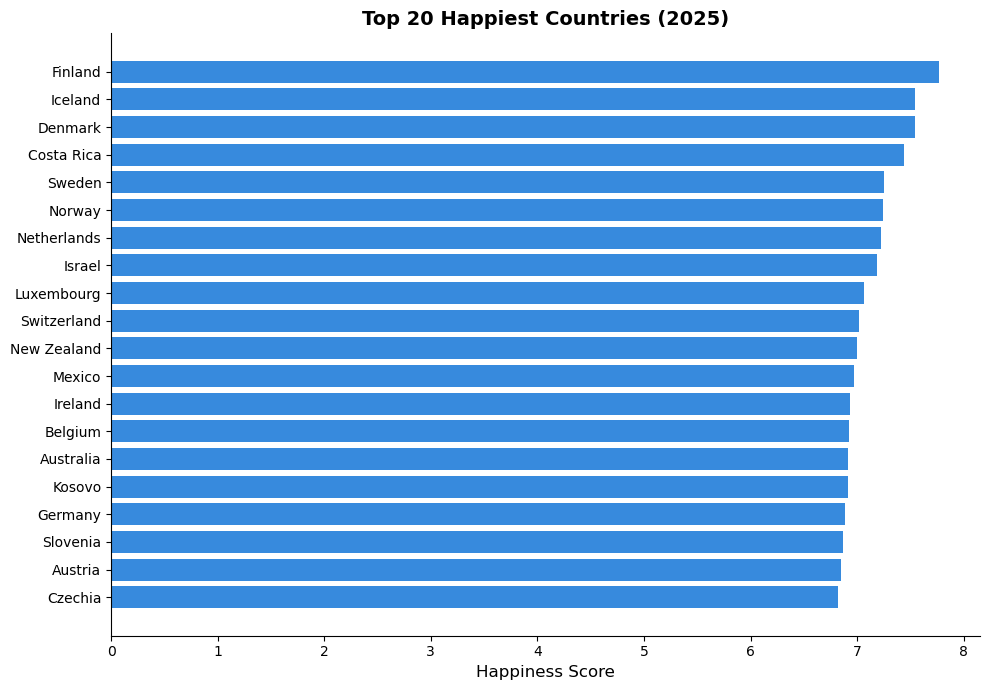

In [46]:
fig, ax = plt.subplots(figsize=(10,7))
df_2025 = df[df['year'] == 2025]
top20 = df_2025.nlargest(20, 'happiness_score')
bars = ax.barh(top20['country'], top20['happiness_score'], color='#378ADD', edgecolor='none')
ax.set_xlabel('Happiness Score', fontsize=12)
ax.set_title('Top 20 Happiest Countries (2025)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../charts/top20_countries.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 2 - GDP vs Happiness scatter plot

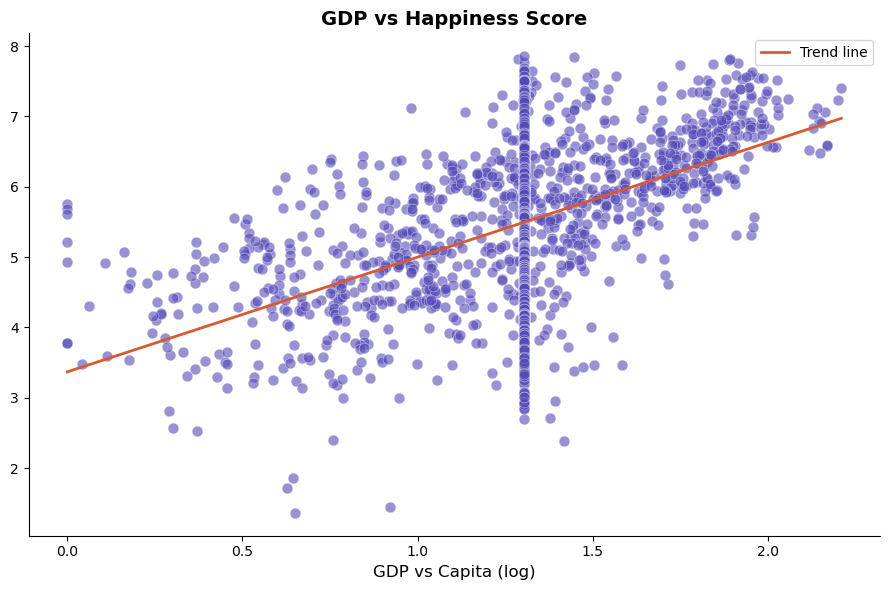

In [47]:
fig, ax = plt.subplots(figsize=(9,6))
scatter = ax.scatter(df['gdp_per_capita'], df['happiness_score'], alpha=0.6, c='#534AB7', edgecolors='white', linewidths=0.4, s=60)

# Add trend line
z = np.polyfit(df['gdp_per_capita'].dropna(), df['happiness_score'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df['gdp_per_capita'].min(), df['gdp_per_capita'].max(), 100)
ax.plot(x_line, p(x_line), color='#D85A30', linewidth=2, label='Trend line')

ax.set_xlabel('GDP vs Capita (log)', fontsize=12)
ax.set_title('GDP vs Happiness Score', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False) # selects the top, right border and hides them
ax.legend()
plt.tight_layout()
plt.savefig('../charts/gdp_vs_happiness.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 3 - Correlation heatmap

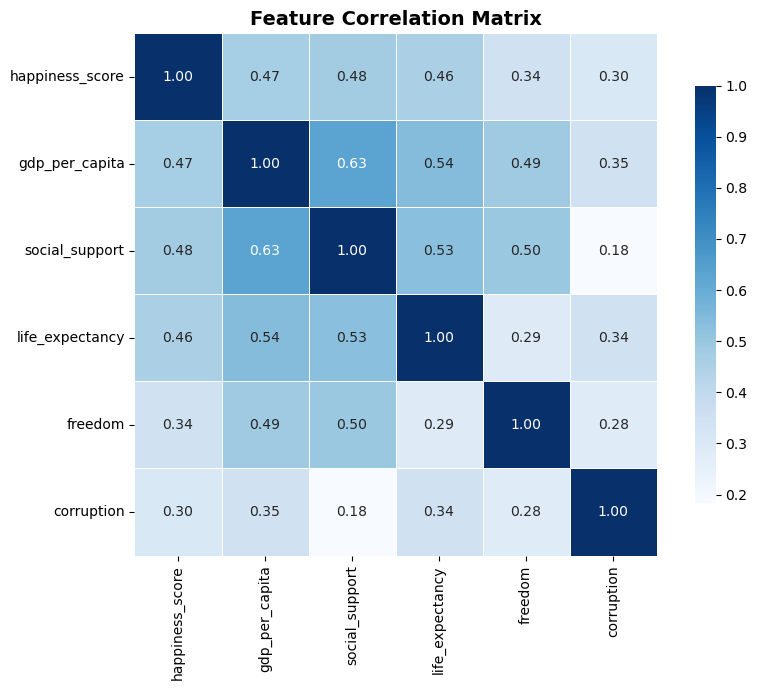

In [48]:
fig, ax = plt.subplots(figsize=(9,7))
corr_matrix = df[['happiness_score','gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'corruption']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5, ax=ax, square=True,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 4 - Regional Happiness Box Plot

In [49]:
if 'Regional indicator' in df.columns:
    fig, ax = plt.subplots(figsize=(12,6))
    regions = df.groupby('Regional indicator')['happiness_score'].median()
    order = regions.sort_values(ascending=False).index
    
    df_plot = df[df['Regional indicator'].isin(order)]
    region_data = [df_plot[df_plot['Region indicator'] == r]['happiness_score'].values for r in order]
    
    bp = ax.boxplot(region_data, patch_artist=True, vert=True)
    colors = ['#378ADD','#1D9E75','#534AB7','#D85A30','#BA7517',
              '#D4537E','#639922','#888780','#E24B4A','#5DCAA5']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    
    ax.set_xticklabels([r.replace(' ', '\n') for r in order], fontsize=8)     
    ax.set_ylabel('Happiness Score', fontsize=12)
    ax.set_title('Happiness Distribution by World Region', fontsize=14, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.savefig('../charts/regional_boxplot', dpi=150, bbox_inches='tight')
    plt.show()

Chart 5 - Happiness score distribution (histogram)

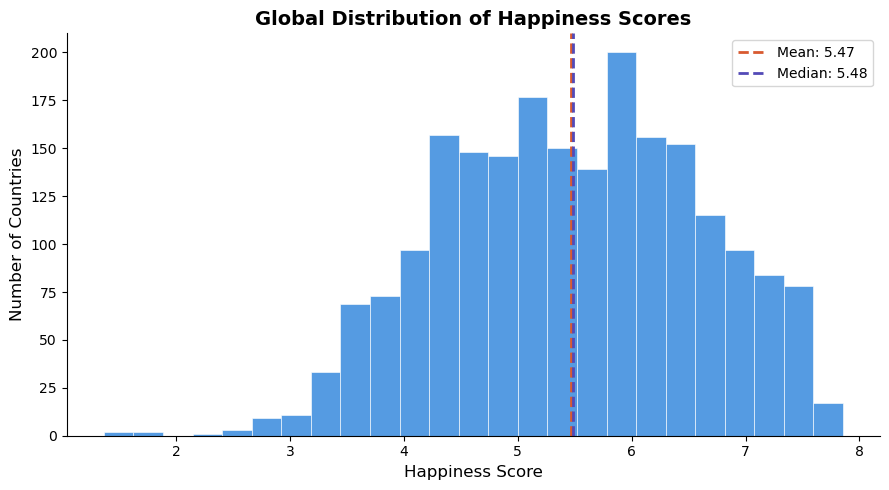

In [50]:
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df['happiness_score'], bins=25, color='#378ADD', edgecolor='white',
        linewidth=0.5, alpha=0.85)
ax.axvline(df['happiness_score'].mean(), color='#D85A30', linestyle='--',
           linewidth=2, label=f"Mean: {df['happiness_score'].mean():.2f}")
ax.axvline(df['happiness_score'].median(), color='#534AB7', linestyle='--',
           linewidth=2, label=f"Median: {df['happiness_score'].median():.2f}")
ax.set_xlabel('Happiness Score', fontsize=12)
ax.set_ylabel('Number of Countries', fontsize=12)
ax.set_title('Global Distribution of Happiness Scores', fontsize=14, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 6 - Multi-factor comparison (radar/grouped bar)

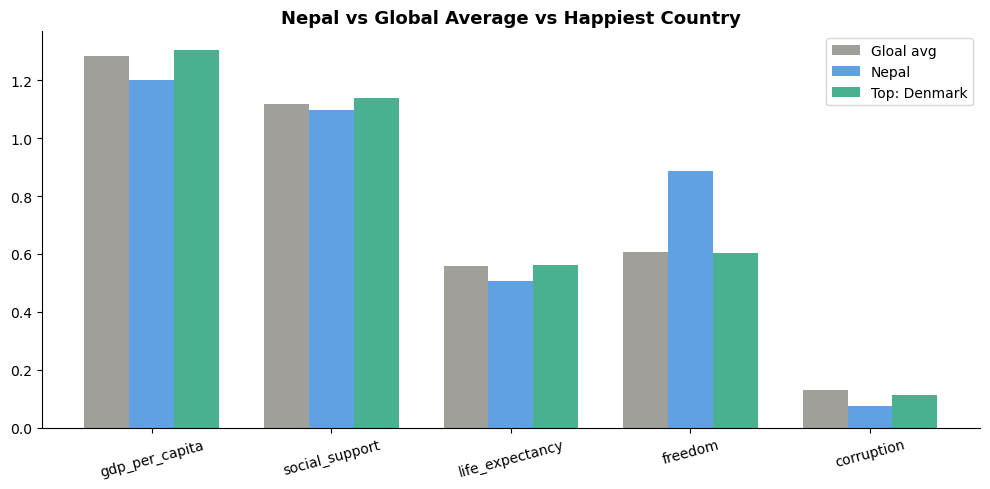

In [51]:
# Compare Nepal vs global average vs top country
factors = ['gdp_per_capita', 'social_support', 'life_expectancy', 'freedom', 'corruption']

nepal_row = df[df['country'].str.contains('Nepal', case=False)]
top_country = df.loc[df['happiness_score'].idxmax()] # returns the row with maximum value
global_avg = df[factors].mean()

fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(factors))
width = 0.25

ax.bar(x - width, global_avg[factors], width, label='Gloal avg', color='#888780', alpha=0.8)
if not nepal_row.empty:
    ax.bar(x, nepal_row[factors].values[0], width, label='Nepal', color='#378ADD', alpha=0.8)
ax.bar(x + width, top_country[factors], width, 
       label=f'Top: {top_country["country"]}', color='#1D9E75', alpha=0.8)

ax.set_xticks(x); ax.set_xticklabels(factors, rotation=15, fontsize=10)
ax.set_title('Nepal vs Global Average vs Happiest Country', fontsize=13, fontweight='bold')
ax.spines[['top','right']].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../charts/nepal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings

1. **Social support is the strongest predictor** of happiness (r = 0.478907)
   Western Europe dominates the top 10 consistently

2. **Social support matters more than freedom** -
   correlation 0.478907 vs 0.342681. Community beats liberty.

3. **Nepal ranks #99 out of 147 countries** with a score of 5.147
   Its lowest factor is GDP per capita, not social support.

4. **The happiness gap is widening** - top 10 countries

5. **Corruption perception** is the only factor negatively
   more corruption = less happiness


## Limitations
- Self-reported survey data — subject to cultural bias
- GDP doesn't capture inequality within countries
- Correlation ≠ causation: GDP and happiness may both 
  be driven by a third factor (political stability, etc.)